Qiskit Multi Qubit Quantum Gates:
-----------------------------------

In [1]:
import math
from pandas import DataFrame as df
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.integrate import odeint, ode
from scipy.integrate import solve_ivp
import pdb # fortroubleshooting code
import seaborn as sns # statistical visualization 
from sklearn.ensemble import RandomForestClassifier # Macine Learning 
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

Quantum Libraries from IBM:

In [2]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_bloch_vector, plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer import Aer

from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit import transpile

from qiskit.quantum_info import Operator

Importing nessesary new libraries:

In [3]:
from qiskit.visualization import plot_state_city # denisty matrix plot
from qiskit.visualization import plot_state_qsphere # used for Multi Qubit Visulaization

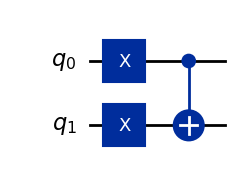

In [4]:
#CX-gate on |11> = |10> (|01> according to Qiskit ordering)
qc_cx = QuantumCircuit(2,name ="qc") #creats a circuit with 2 qubits, Note by default, every circuit starts with |00>
qc_cx.x(0) #X gate on 1st Qubit (remeber this is q1 in the drawing - according to little-endian ordering)
qc_cx.x(1) #X gate on 2nd Qubit (remeber this is q0 in the drawing)
qc_cx.cx(0,1) #CX Gate with 1st Qubit as Control and 2nd Qubit as Target
qc_cx.draw('mpl')

Density Matrix Plot for CNOT Gate
---------------------------------


Quantum State is: [0.+0.j 1.+0.j 0.+0.j 0.+0.j]


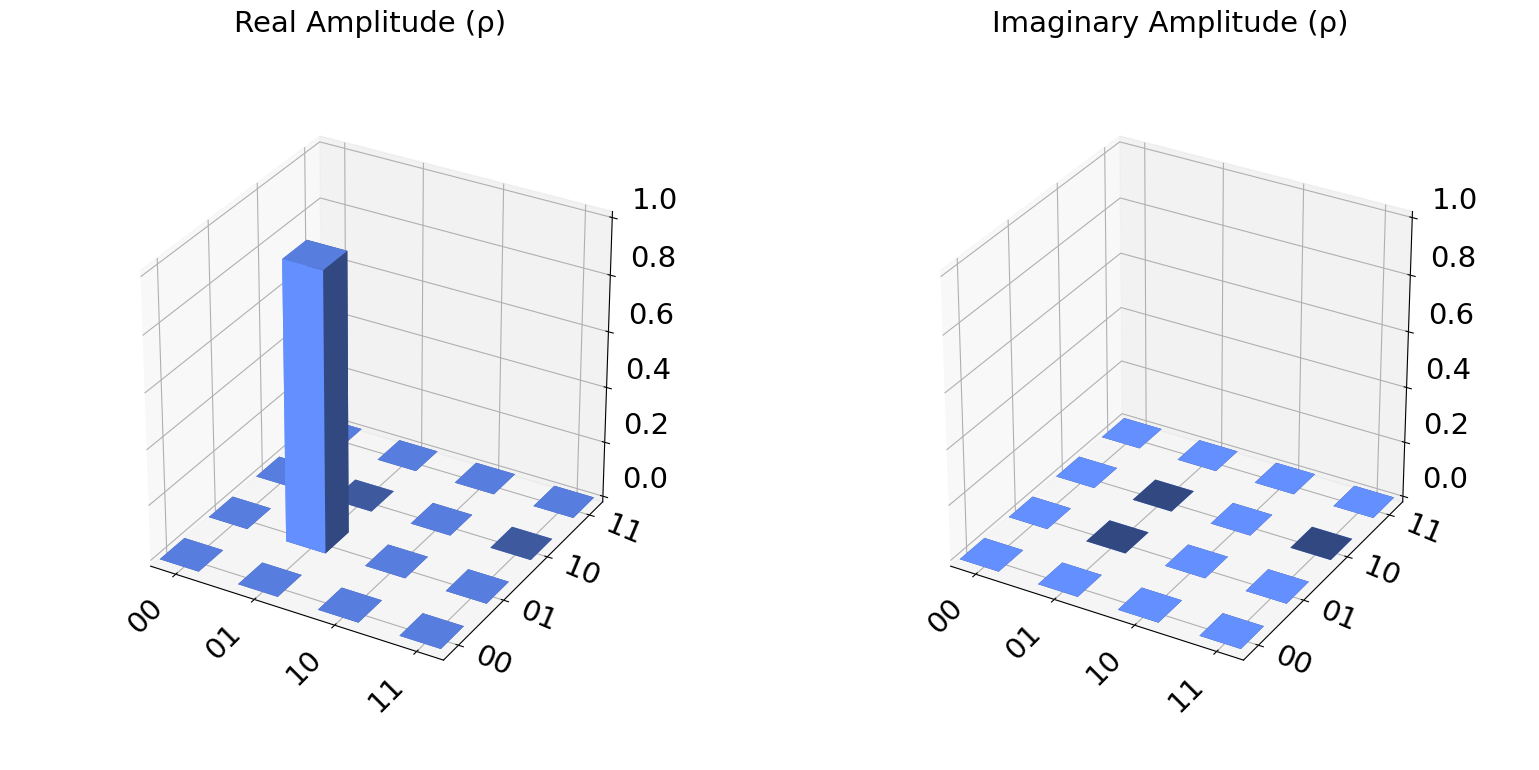

In [5]:
# To get the eigenvector use the statevector simulator in the core of the circuit
state_qc_cx = Statevector.from_instruction(qc_cx)
state_rounded_qc_cx = np.round(state_qc_cx.data, 3)

print("\nQuantum State is:", state_rounded_qc_cx)
plot_bloch_multivector(state_rounded_qc_cx)

#Plot density matrix
plot_state_city(state_rounded_qc_cx)

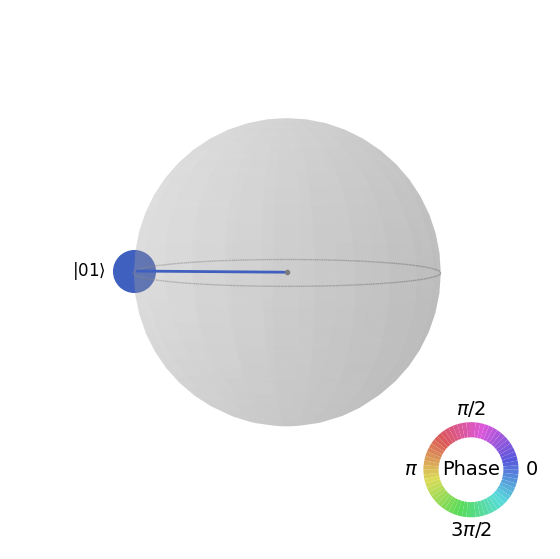

In [6]:
#Plot the Qsphere
plot_state_qsphere(state_rounded_qc_cx)

Here the blue blob thickness tells you the probability (thin dot would be low probility)

Unitary Operator for CNOT Gate:
---------------------------------

In [7]:
unitary = Operator(qc_cx).data   # NumPy array
print(unitary)

[[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]


Running CNOT Gate Circuit using QASM Simulator:
---------------------------------

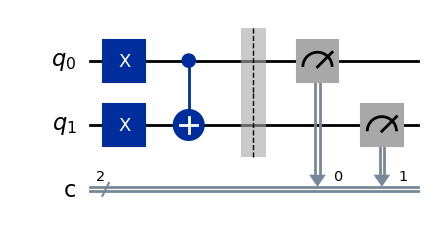

In [8]:
qc_cx = QuantumCircuit(2, 2, name="qc")
qc_cx.x(0)
qc_cx.x(1)
qc_cx.cx(0,1)
qc_cx.barrier() 
#qc_cx.measure(0,0)# one qbit going into a classical bit
#qc_cx.measure(1,1)
qc_cx.measure([0,1],[0,1])
qc_cx.draw('mpl')


Total Counts are: {'01': 1000}


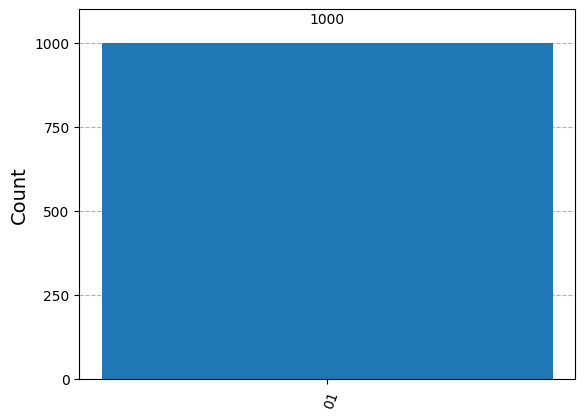

In [9]:
backend = Aer.get_backend('qasm_simulator') 
"""
#A qasm_simulator is a software tool that runs on a classical computer to emulate the execution of a quantum circuit 
#defined in the Quantum Assembly Language (QASM).
"""
qc_cx_t = transpile(qc_cx, backend)
result = backend.run(qc_cx_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

CNOT Gate using CZ and H Gates:
--------------------------------

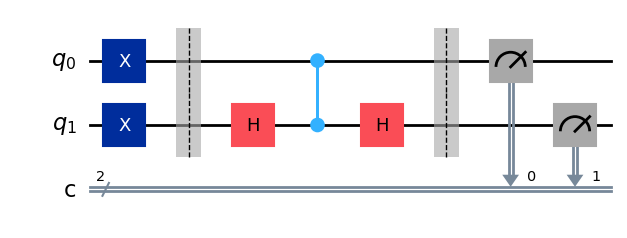

In [10]:
qc_cx = QuantumCircuit(2, 2, name="qc")
qc_cx.x(0)
qc_cx.x(1)
qc_cx.barrier() 
qc_cx.h(1)
qc_cx.cz(0,1)
qc_cx.h(1)
qc_cx.barrier()
qc_cx.measure([0,1],[0,1])
qc_cx.draw('mpl')


Total Counts are: {'01': 1000}


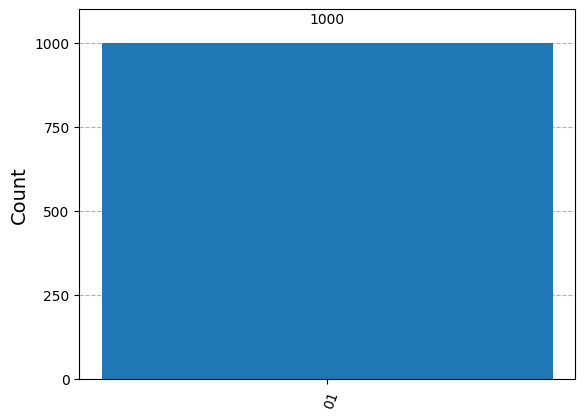

In [17]:
backend = Aer.get_backend('qasm_simulator') 
"""
#A qasm_simulator is a software tool that runs on a classical computer to emulate the execution of a quantum circuit 
#defined in the Quantum Assembly Language (QASM).
"""
qc_cx_t = transpile(qc_cx, backend)
result = backend.run(qc_cx_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

Quantum CZ Gate:
----------------

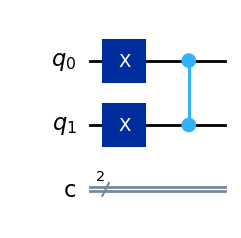

In [18]:
qc_cz = QuantumCircuit(2, 2, name="qc")
qc_cz.x(0) # |0> by default
qc_cz.x(1) # |0> by default
qc_cz.cz(0,1)
#qc_cz.measure([0,1],[0,1])
qc_cz.draw('mpl')

In [19]:
#Plot the Qsphere
plot_state_qsphere(state_rounded_qc_cz)

NameError: name 'state_rounded_qc_cz' is not defined

In [20]:
unitary = Operator(qc_cz).data   # NumPy array
print(unitary)

[[ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  0.+0.j  0.+0.j  0.+0.j]]


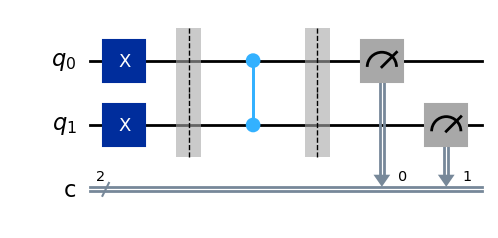

In [21]:
qc_cz = QuantumCircuit(2, 2, name="qc")
qc_cz.x(0) # |0> by default
qc_cz.x(1) # |0> by default
qc_cz.barrier() 
qc_cz.cz(0,1)
qc_cz.barrier()
qc_cz.measure([0,1],[0,1])
qc_cz.draw('mpl')


Total Counts are: {'11': 1000}


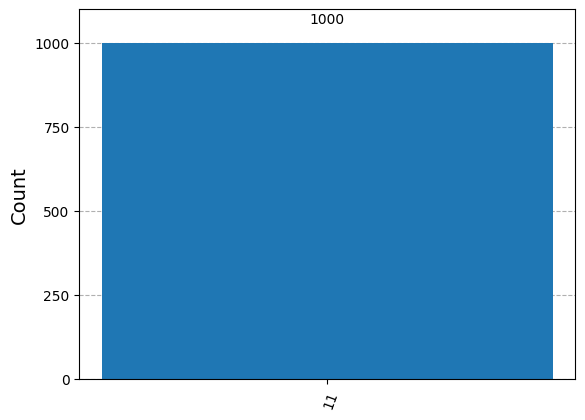

In [22]:
backend = Aer.get_backend('qasm_simulator') 

qc_cz_t = transpile(qc_cz, backend)
result = backend.run(qc_cz_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

CZ Gate using CNOT and H gates:
----------------

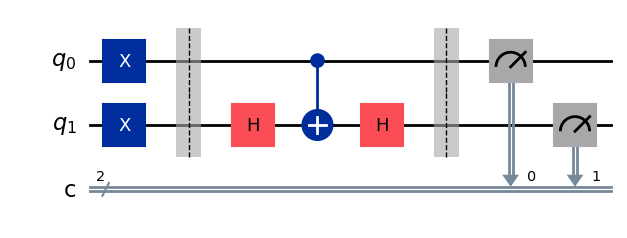

In [23]:
qc_cz = QuantumCircuit(2, 2, name="qc")
qc_cz.x(0)
qc_cz.x(1)
qc_cz.barrier() 
qc_cz.h(1)
qc_cz.cx(0,1)
qc_cz.h(1)
qc_cz.barrier()
qc_cz.measure([0,1],[0,1])
qc_cz.draw('mpl')


Total Counts are: {'11': 1000}


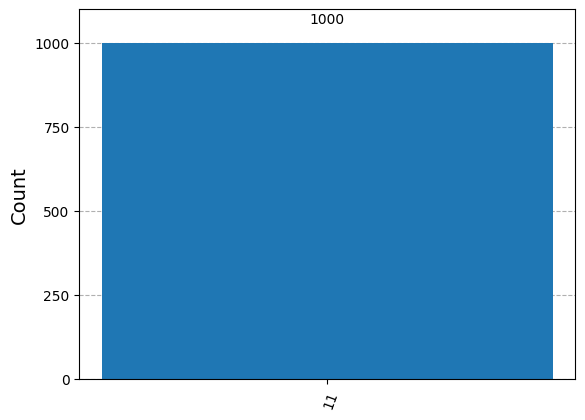

In [24]:
backend = Aer.get_backend('qasm_simulator') 

qc_cz_t = transpile(qc_cz, backend)
result = backend.run(qc_cz_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

Quantum CH gate:
----------------

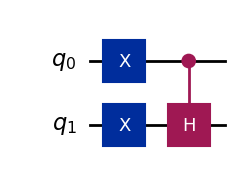

In [25]:
qc_ch = QuantumCircuit(2, name ="qc")
qc_ch.x(0)
qc_ch.x(1)
qc_ch.ch(0,1)
qc_ch.draw('mpl')

Density Plot for CH Gate


Quantum State is: [ 0.   +0.j  0.707+0.j  0.   +0.j -0.707+0.j]


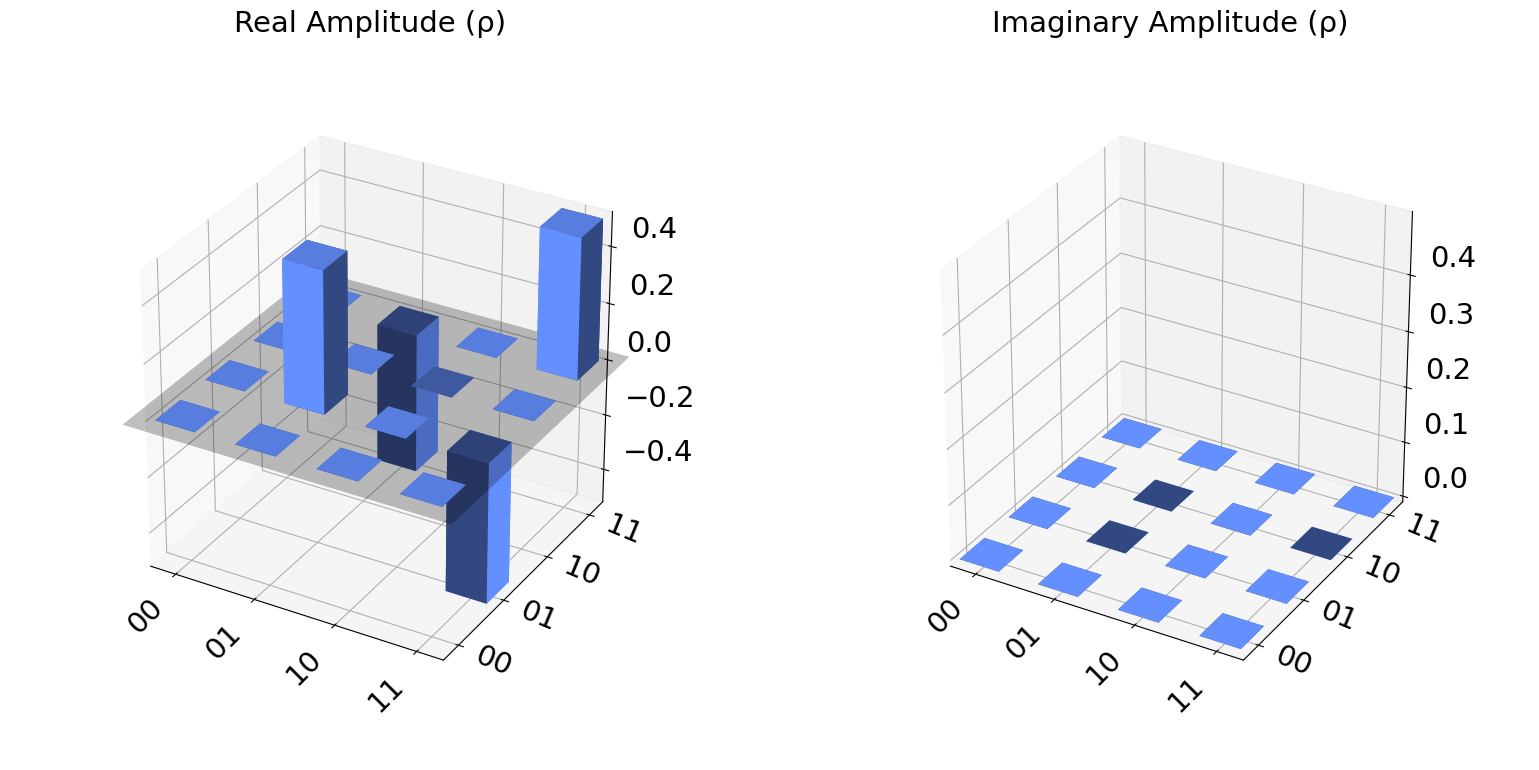

In [26]:
# To get the eigenvector use the statevector simulator in the core of the circuit
state_qc_ch = Statevector.from_instruction(qc_ch)
state_rounded_qc_ch = np.round(state_qc_ch.data, 3)

print("\nQuantum State is:", state_rounded_qc_ch)
plot_bloch_multivector(state_rounded_qc_ch)

#Plot density matrix
plot_state_city(state_rounded_qc_ch)

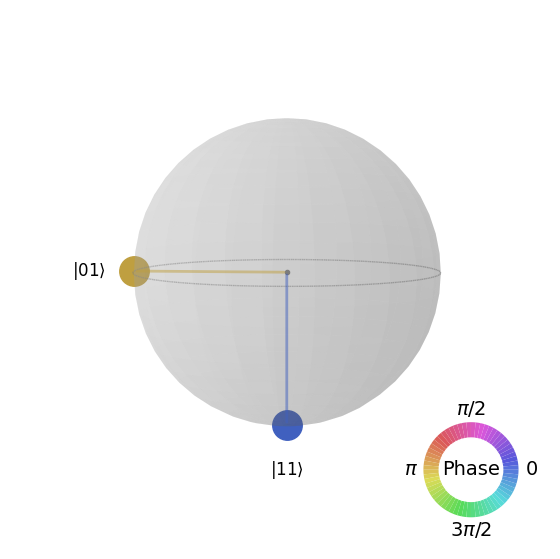

In [27]:
#Plot the Qsphere
plot_state_qsphere(state_rounded_qc_ch)

In [28]:
unitary = Operator(qc_ch).data   # NumPy array
print(unitary)

[[ 0.        +0.j  0.        +0.j  0.        +0.j  1.        +0.j]
 [ 0.70710678+0.j  0.        +0.j  0.70710678+0.j  0.        +0.j]
 [ 0.        +0.j  1.        +0.j  0.        +0.j  0.        +0.j]
 [-0.70710678+0.j  0.        +0.j  0.70710678+0.j  0.        +0.j]]


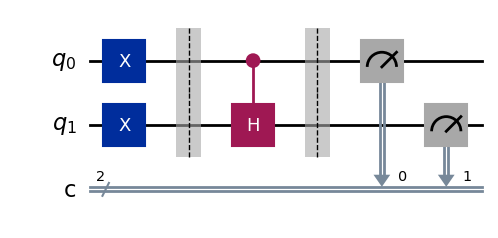

In [29]:
qc_ch = QuantumCircuit(2,2,name ="qc")
qc_ch.x(0)
qc_ch.x(1)
qc_ch.barrier() 
qc_ch.ch(0,1)
qc_ch.barrier() 
qc_ch.measure([0,1],[0,1])
qc_ch.draw('mpl')


Total Counts are: {'01': 499, '11': 501}


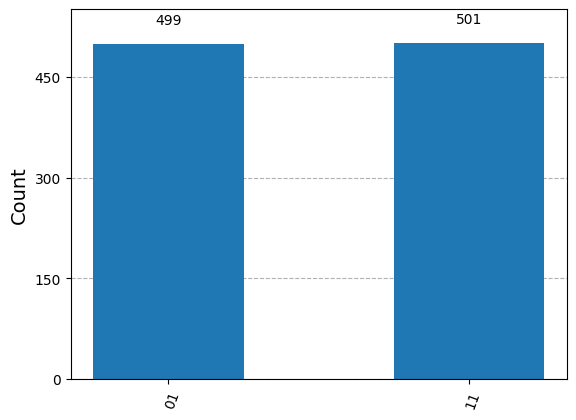

In [30]:
backend = Aer.get_backend('qasm_simulator') 

qc_ch_t = transpile(qc_ch, backend)
result = backend.run(qc_ch_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

CH Gate using CNOT & Ry Gates:
-------------------------------

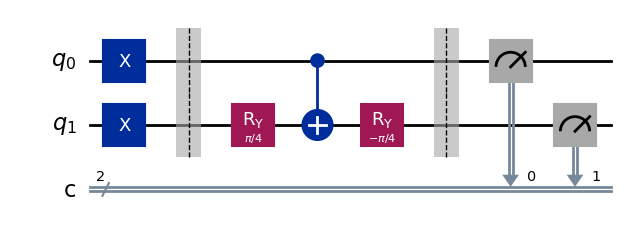

In [31]:
qc_ch = QuantumCircuit(2,2,name ="qc")
qc_ch.x(0)
qc_ch.x(1)
qc_ch.barrier() 
qc_ch.ry(np.pi/4,1)
qc_ch.cx(0,1)
qc_ch.ry(-np.pi/4,1)
qc_ch.barrier() 
qc_ch.measure([0,1],[0,1])
qc_ch.draw('mpl')


Total Counts are: {'11': 506, '01': 494}


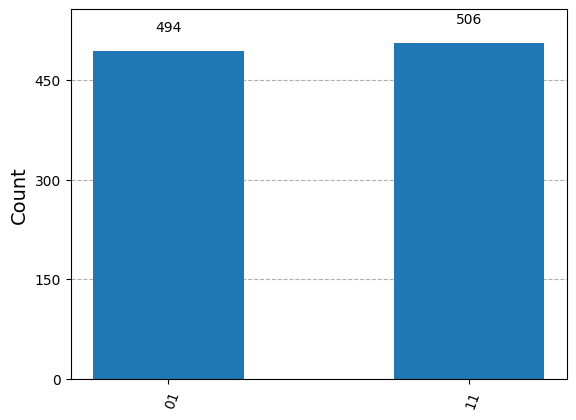

In [32]:
backend = Aer.get_backend('qasm_simulator') 

qc_ch_t = transpile(qc_ch, backend)
result = backend.run(qc_ch_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

Quantum SWAP Gate:
-------------------------------

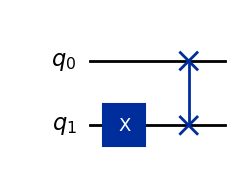

In [33]:
qc_sw = QuantumCircuit(2,name ="qc")
qc_sw.x(1)
qc_sw.swap(0,1)
qc_sw.draw("mpl")


Quantum State is: [0.+0.j 1.+0.j 0.+0.j 0.+0.j]


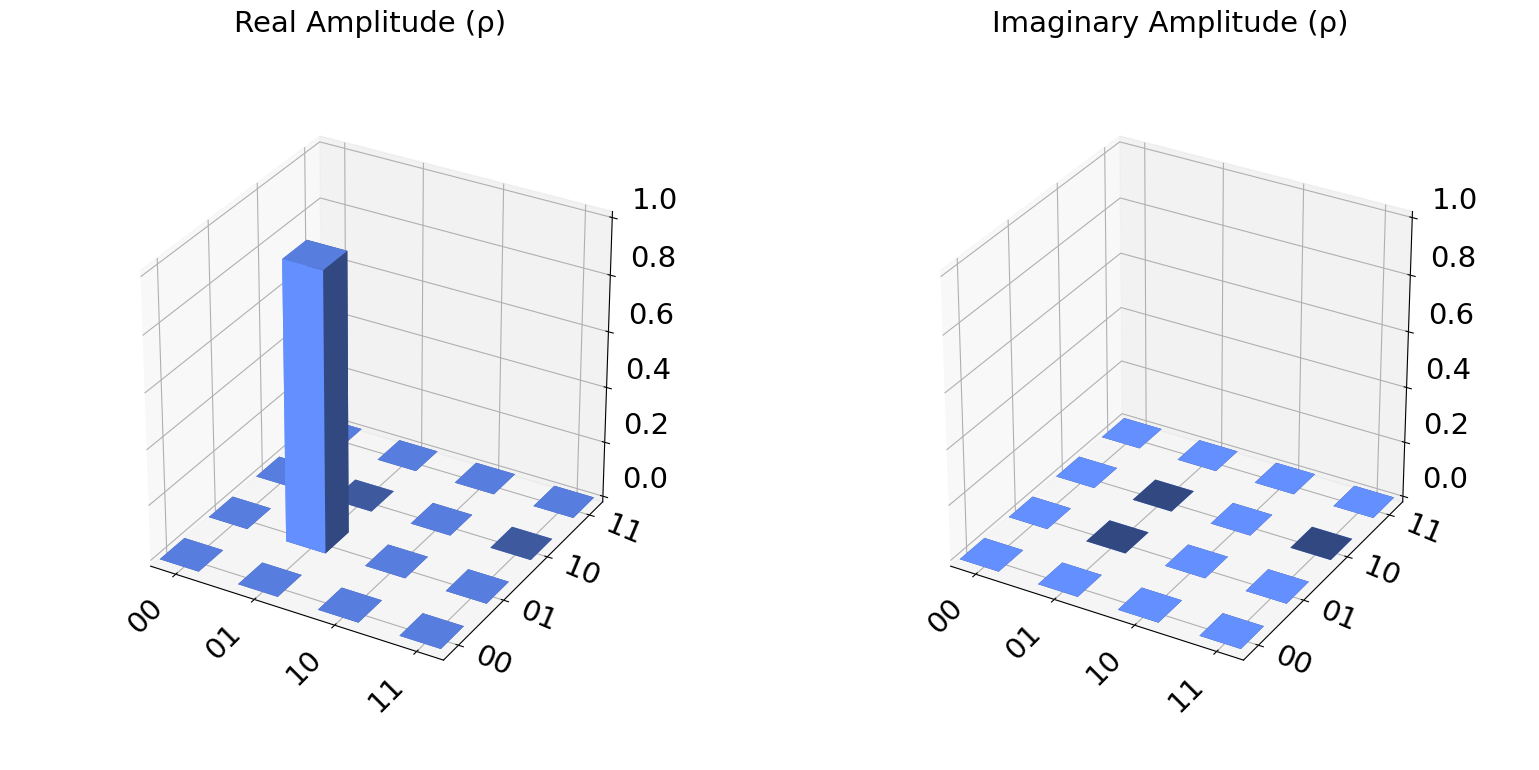

In [34]:
state_qc_sw = Statevector.from_instruction(qc_sw)
state_rounded_qc_sw = np.round(state_qc_sw.data, 3)

print("\nQuantum State is:", state_rounded_qc_sw)
plot_bloch_multivector(state_rounded_qc_sw)

#Plot density matrix
plot_state_city(state_rounded_qc_sw)

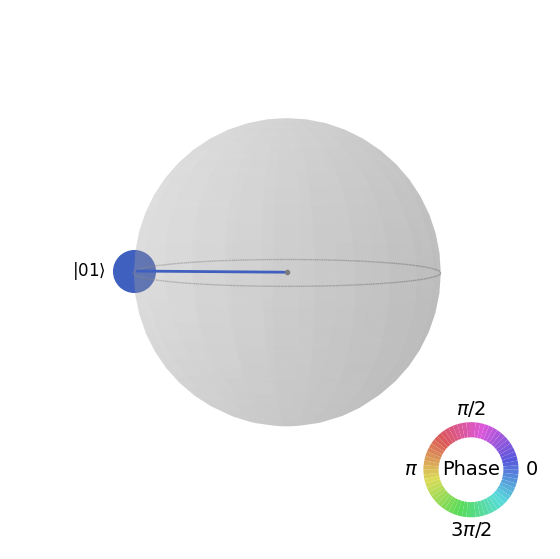

In [35]:
#Plot the Qsphere
plot_state_qsphere(state_rounded_qc_sw)

In [36]:
unitary = Operator(qc_sw).data   # NumPy array
print(unitary)

[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


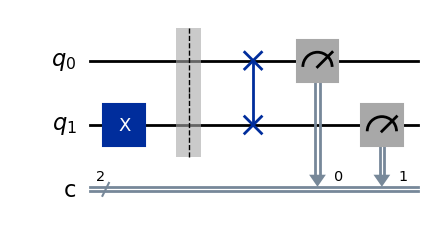

In [37]:
qc_sw = QuantumCircuit(2,2,name ="qc")
#qc_sw.x(0)
qc_sw.x(1)# X gate on the second qubit
qc_sw.barrier() 
qc_sw.swap(0,1)
qc_sw.measure([0,1],[0,1])
qc_sw.draw('mpl')


Total Counts are: {'01': 1000}


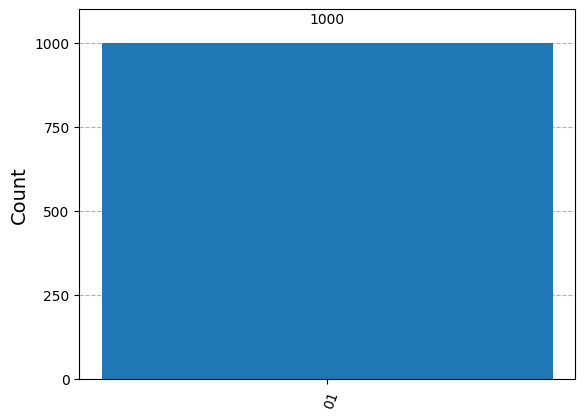

In [38]:
backend = Aer.get_backend('qasm_simulator') 

qc_sw_t = transpile(qc_sw, backend)
result = backend.run(qc_sw_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

SWAP Gate using CNOT Gates - 1st Method:
-------------------------------

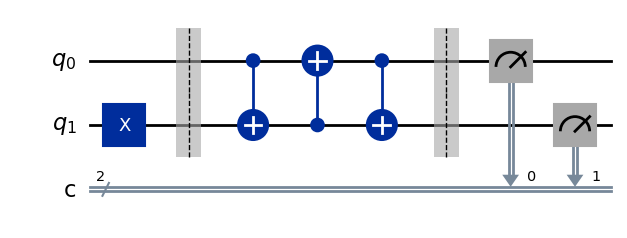

In [39]:
qc_sw = QuantumCircuit(2,2,name ="qc")
#qc_sw.x(0)
qc_sw.x(1)# X gate on the second qubit
qc_sw.barrier() 
qc_sw.cx(0,1)
qc_sw.cx(1,0)
qc_sw.cx(0,1)
qc_sw.barrier()
qc_sw.measure([0,1],[0,1])
qc_sw.draw('mpl')


Total Counts are: {'01': 1000}


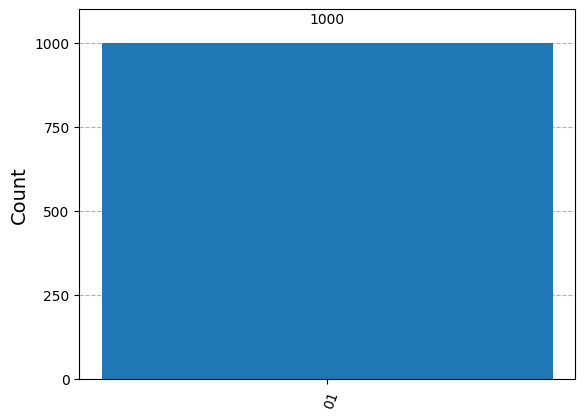

In [40]:
backend = Aer.get_backend('qasm_simulator') 

qc_sw_t = transpile(qc_sw, backend)
result = backend.run(qc_sw_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

SWAP Gate using CNOT Gates - 2nd Method:
-------------------------------

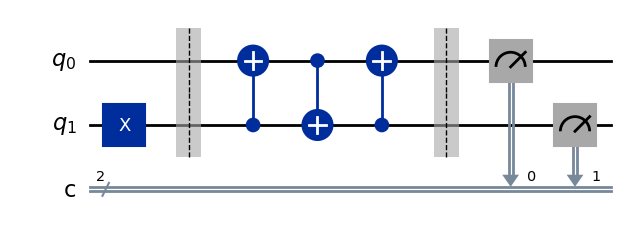

In [41]:
qc_sw = QuantumCircuit(2,2,name ="qc")
#qc_sw.x(0)
qc_sw.x(1)# X gate on the second qubit
qc_sw.barrier() 
qc_sw.cx(1,0)
qc_sw.cx(0,1)
qc_sw.cx(1,0)
qc_sw.barrier()
qc_sw.measure([0,1],[0,1])
qc_sw.draw('mpl')


Total Counts are: {'01': 1000}


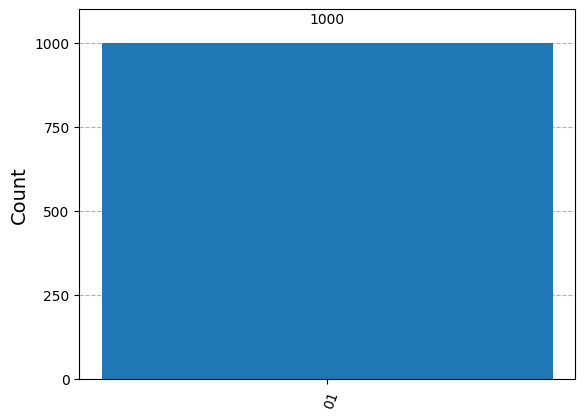

In [42]:
backend = Aer.get_backend('qasm_simulator') 

qc_sw_t = transpile(qc_sw, backend)
result = backend.run(qc_sw_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

The Bell State:
-------------------------------

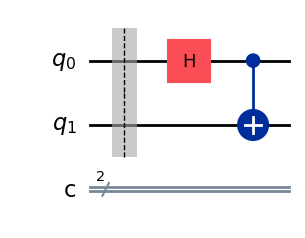

In [43]:
qc_bell = QuantumCircuit(2,2,name ="qc")
#qc_sw.x(0)
#qc_bell.x(1)# X gate on the second qubit
qc_bell.barrier() 
qc_bell.h(0)
qc_bell.cx(0,1)
#qc_sw.cx(1,0)
#qc_sw.barrier()
#qc_sw.measure([0,1],[0,1])
qc_bell.draw('mpl')


Quantum State is: [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]


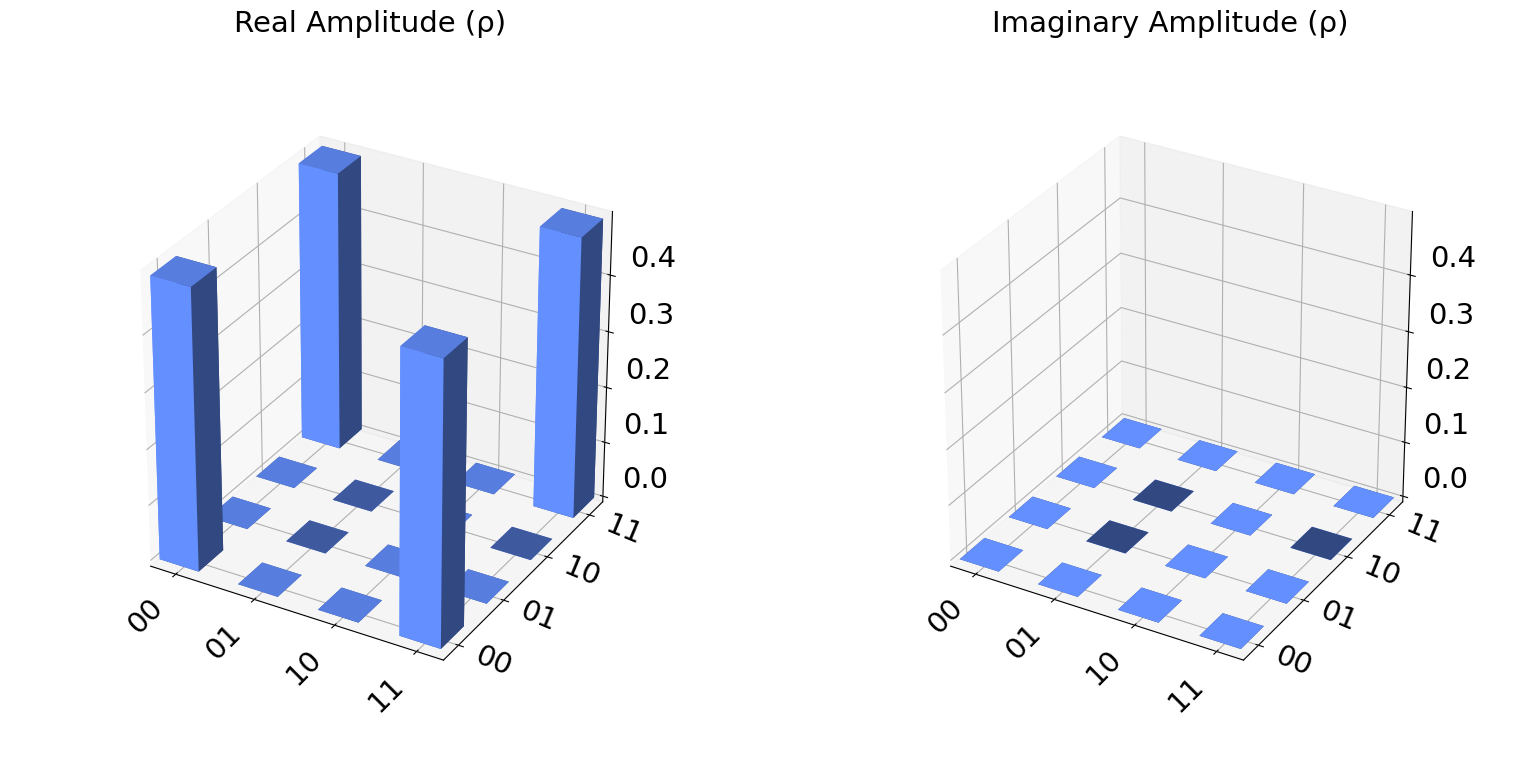

In [44]:
state_qc_bell = Statevector.from_instruction(qc_bell)
state_rounded_qc_bell = np.round(state_qc_bell.data, 3)

print("\nQuantum State is:", state_rounded_qc_bell)
plot_bloch_multivector(state_rounded_qc_bell)

#Plot density matrix
plot_state_city(state_rounded_qc_bell)

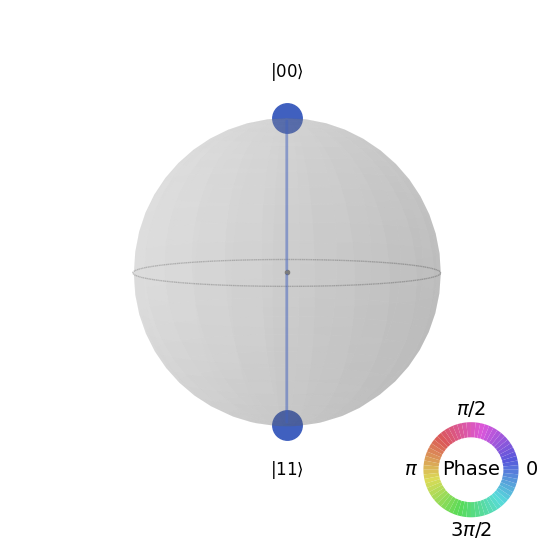

In [45]:
#Plot the Qsphere
plot_state_qsphere(state_rounded_qc_bell)

In [46]:
unitary = Operator(qc_bell).data   # NumPy array
print(unitary)

[[ 0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j -0.70710678+0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j  0.        +0.j  0.        +0.j]]


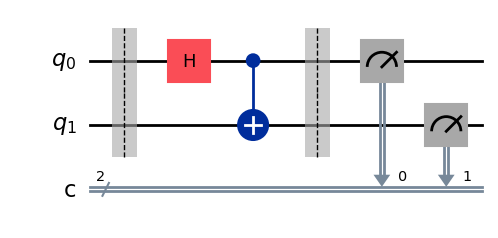

In [47]:
qc_bell = QuantumCircuit(2,2,name ="qc")
#qc_sw.x(0)
#qc_bell.x(1)# X gate on the second qubit
qc_bell.barrier() 
qc_bell.h(0)
qc_bell.cx(0,1)
qc_bell.barrier()
qc_bell.measure([0,1],[0,1])
qc_bell.draw('mpl')


Total Counts are: {'00': 504, '11': 496}


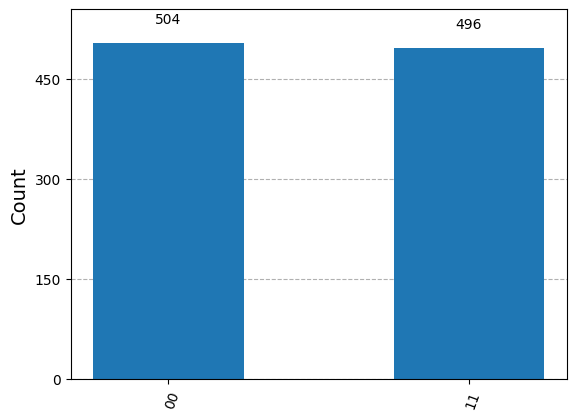

In [48]:
backend = Aer.get_backend('qasm_simulator') 

qc_bell_t = transpile(qc_bell, backend)
result = backend.run(qc_bell_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

Quantum CCX/CCNOT or Toffoli Gate:
-------------------------------

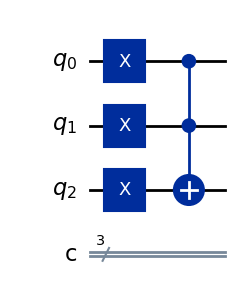

In [49]:
#CCX-gate on |111> = |110> (|011> in Qiskit odering)
qc_ccx = QuantumCircuit(3,3,name="qc")
qc_ccx.x(0)
qc_ccx.x(1)
qc_ccx.x(2)
qc_ccx.ccx(0,1,2)# CNOT gate applied on the 3rd qubit
qc_ccx.draw('mpl')


Quantum State is: [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


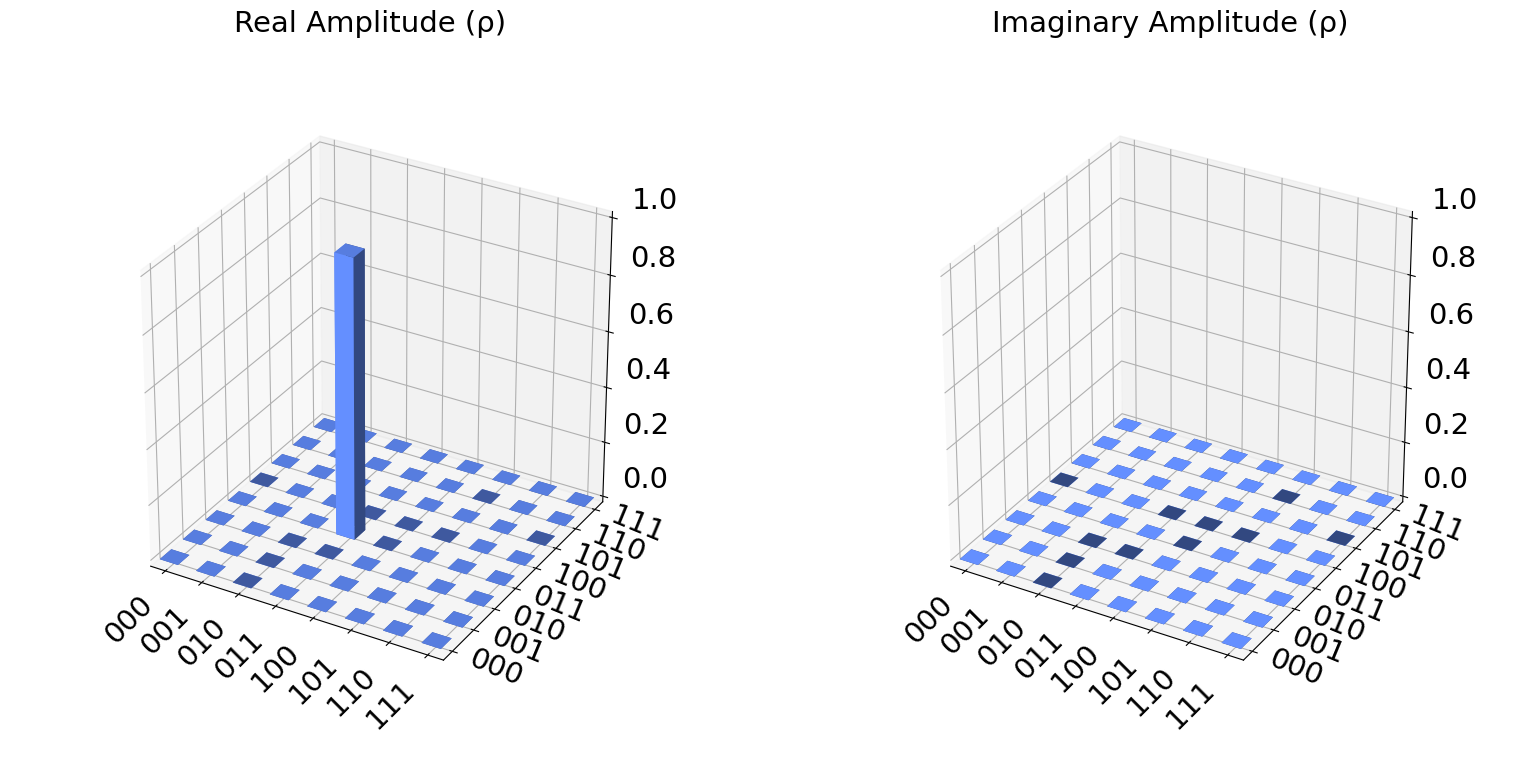

In [50]:
state_qc_ccx = Statevector.from_instruction(qc_ccx)
state_rounded_qc_ccx = np.round(state_qc_ccx.data, 3)

print("\nQuantum State is:", state_rounded_qc_ccx)
plot_bloch_multivector(state_rounded_qc_bell)

#Plot density matrix
plot_state_city(state_rounded_qc_ccx)

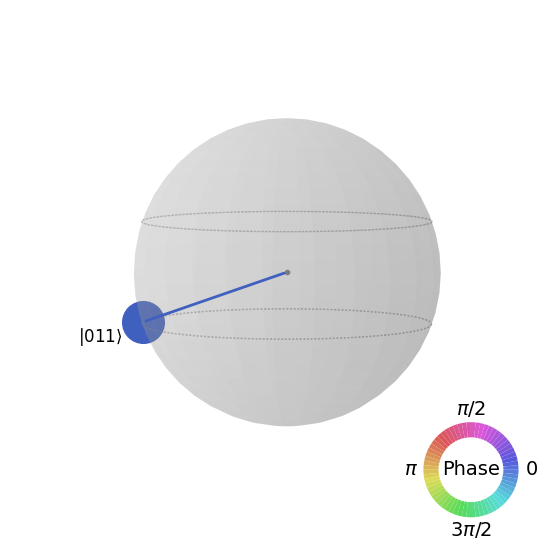

In [51]:
#Plot the Qsphere
plot_state_qsphere(state_rounded_qc_ccx)

In [52]:
unitary = Operator(qc_ccx).data   # NumPy array
print(unitary)

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]]


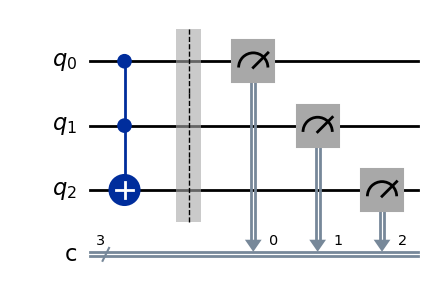

In [53]:
qc_ccx = QuantumCircuit(3,3,name="qc")
#qc_x.x(0)
#qc_x.x(1)
qc_ccx.ccx(0,1,2)# CNOT gate applied on the 3rd qubit
qc_ccx.barrier(0,1,2)
#qc_ccx.measure([0,1,2],[0,1,2])
qc_ccx.measure(0,0)# one qbit going into a classical bit
qc_ccx.measure(1,1)
qc_ccx.measure(2,2)
qc_ccx.draw('mpl')


Total Counts are: {'000': 1000}


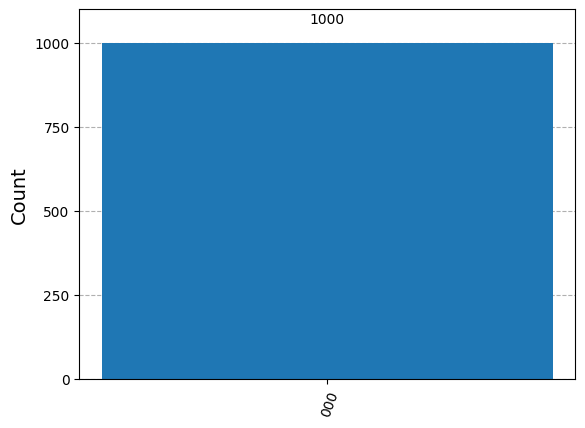

In [54]:
backend = Aer.get_backend('qasm_simulator') 

qc_ccx_t = transpile(qc_ccx, backend)
result = backend.run(qc_ccx_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

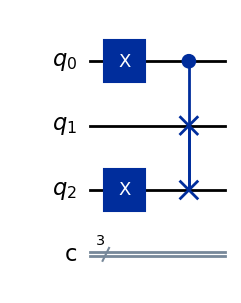

In [55]:
#Fredkin-gate/CSWAP-gate on |101> = |110> (|011> in Qiskit odering)
qc_csw = QuantumCircuit(3,3,name="qc")
qc_csw.x(0)
#qc_csw.x(1)
qc_csw.x(2)
qc_csw.cswap(0,1,2)# CSWAP gate w/1st qubit as control 
qc_csw.draw('mpl')


Quantum State is: [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


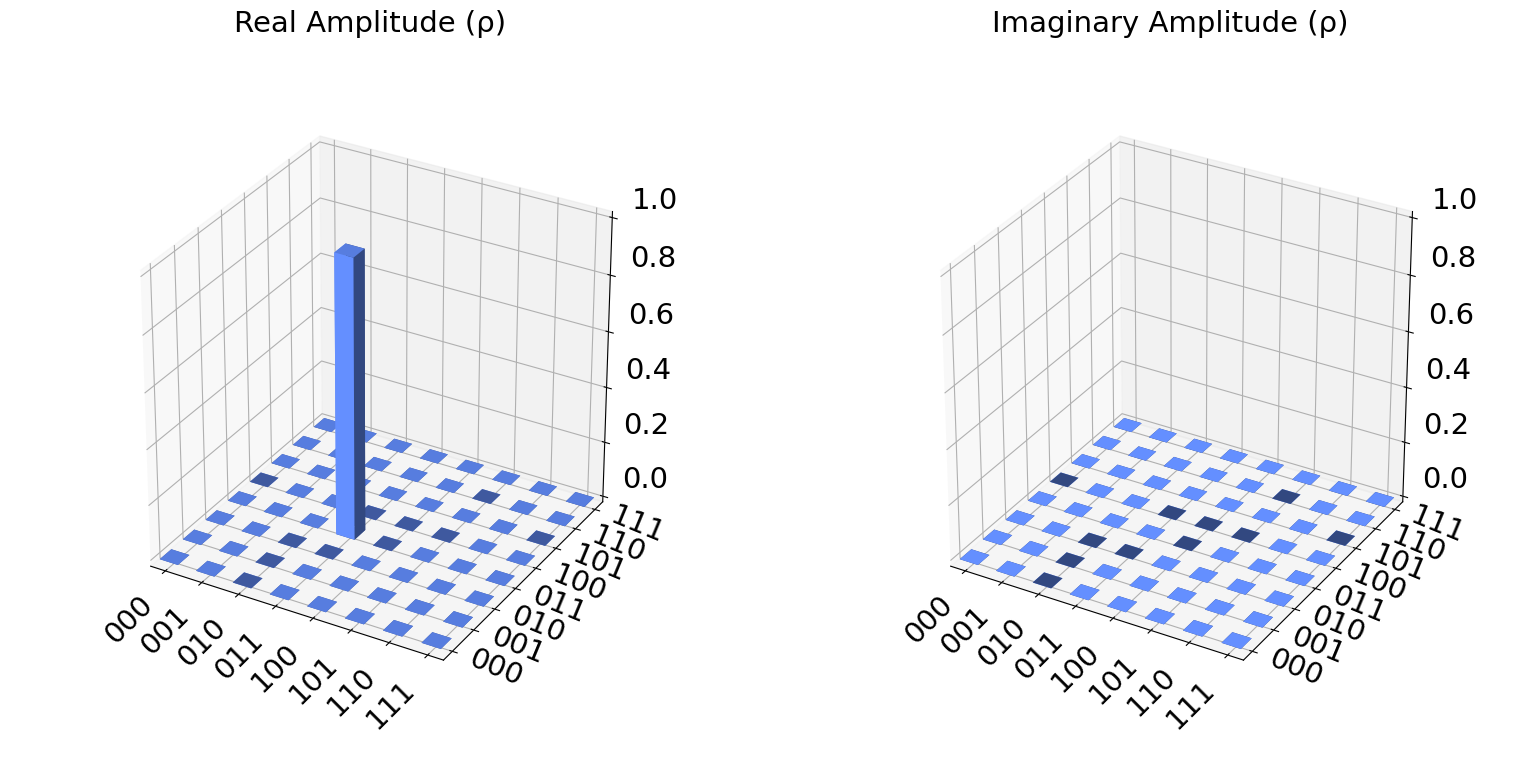

In [56]:
state_qc_csw = Statevector.from_instruction(qc_csw)
state_rounded_qc_csw = np.round(state_qc_csw.data, 3)

print("\nQuantum State is:", state_rounded_qc_csw)
plot_bloch_multivector(state_rounded_qc_csw)

#Plot density matrix
plot_state_city(state_rounded_qc_csw)

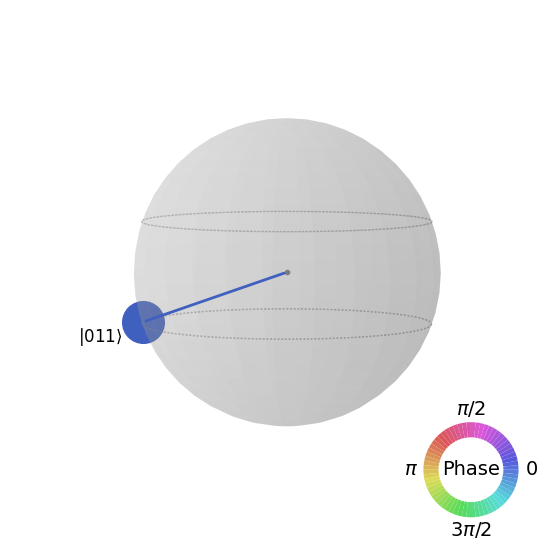

In [57]:
#Plot the Qsphere
plot_state_qsphere(state_rounded_qc_csw)

In [58]:
unitary = Operator(qc_csw).data   # NumPy array
print(unitary)

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


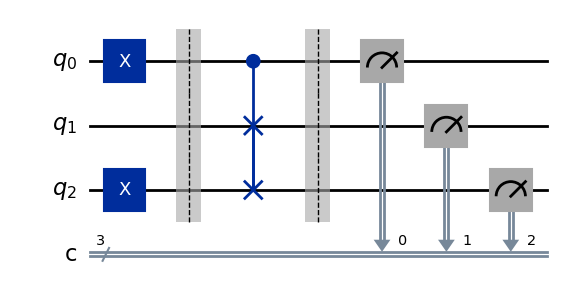

In [59]:
qc_csw = QuantumCircuit(3,3,name="qc")
qc_csw.x(0)
#qc_csw.x(1)
qc_csw.x(2)
qc_csw.barrier(0,1,2)
qc_csw.cswap(0,1,2)# CSWAP gate w/1st qubit as control 
#qc_csw.measure(0,0)
#qc_csw.measure(1,1)
#qc_csw.measure(2,2)
qc_csw.barrier(0,1,2)
qc_csw.measure([0,1,2],[0,1,2])
qc_csw.draw('mpl')


Total Counts are: {'011': 1000}


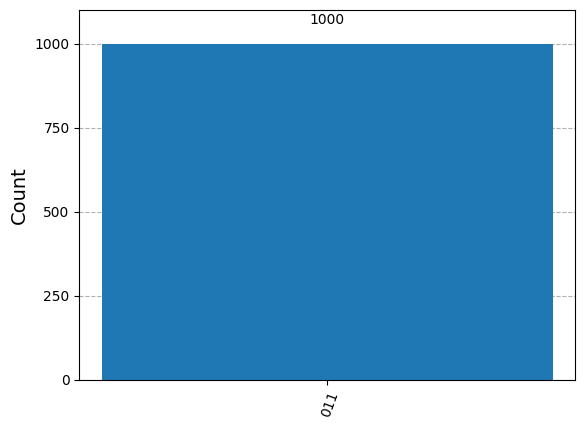

In [60]:
backend = Aer.get_backend('qasm_simulator') 

qc_csw_t = transpile(qc_csw, backend)
result = backend.run(qc_csw_t, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)